In [2]:
import copy
import pickle
import inspect
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from rich import progress
from scipy import constants

from rich.progress import (
    Progress,
    BarColumn,
    TextColumn,
    TransferSpeedColumn,
    TimeRemainingColumn,
)
plt.rcParams.update({"font.size": 10})
class TaskSpeed(progress.ProgressColumn):
    def render(self, task):
        if task.speed is None:
            return ""
        elif task.speed >= 0.1:
            return f"{(task.speed or 0):.1f}/s"
        else:
            return f"{(1 / task.speed or 0):.1f} s/i"

# --- Define the file wrapper ---
class RichProgressFileWrapper:
    def __init__(self, file_obj, progress, task_id):
        self.file_obj = file_obj
        self.progress = progress
        self.task_id = task_id

    def read(self, size=-1):
        """Read bytes and update the progress bar."""
        chunk = self.file_obj.read(size)
        self.progress.update(self.task_id, advance=len(chunk))
        return chunk

    def __getattr__(self, name):
        """Delegate other attribute access to the original file object."""
        return getattr(self.file_obj, name)

## Calculate DET chamber vx distributions

In [25]:
import numpy as np

# 1. Generate your range
offsets = np.arange(-25, 25, 1) * 1e-3

# 2. Convert the array to a space-separated string
offsets_str = " ".join(map(str, offsets))

# 3. Use the {variable} syntax inside the ! command
!python read_analyze_files.py --root "saved_trajectories_vz_184ms_mean" --aperture_ys_offset {offsets_str} --aperture_xs 20e-3 --aperture_ys 2e-3

XS Array: [0.02] | Type: <class 'numpy.ndarray'>
YS Array: [0.002] | Type: <class 'numpy.ndarray'>
YS Offset Array: [-0.025 -0.024 -0.023 -0.022 -0.021 -0.02  -0.019 -0.018 -0.017 -0.016
 -0.015 -0.014 -0.013 -0.012 -0.011 -0.01  -0.009 -0.008 -0.007 -0.006
 -0.005 -0.004 -0.003 -0.002 -0.001  0.     0.001  0.002  0.003  0.004
  0.005  0.006  0.007  0.008  0.009  0.01   0.011  0.012  0.013  0.014
  0.015  0.016  0.017  0.018  0.019  0.02   0.021  0.022  0.023  0.024] | Type: <class 'numpy.ndarray'>
Current root is: saved_trajectories_vz_184ms_mean
Starting parallel processing of 12 files on 32 cores...

Overall Progress -----------------------------   0% •  0/12 • 0:00:00 | -:--:--
Overall Progress -----------------------------   0% •  0/12 • 0:00:00 | -:--:--
Overall Progress -----------------   0% •  0/12             • 0:00:00 | -:--:--
 Loading 0.0.pkl -----------------   0% •        0/29212398 • 0:00:00 | -:--:--
   Overall Progress ---------------   0% •  0/12            • 0:00:00

## Import DET chamber vx distributions

In [26]:
with open("final_vs_distribution.pkl", "rb") as f:
    final_vs_distribution = pickle.load(f)


In [27]:
counts_vs_vx = {}
bin_edges = np.linspace(-2, 2, 41)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

In [28]:

for k1, data1 in final_vs_distribution.items(): # k1 is mF=0
    for k2, data2 in data1.items(): # k2 is distribution type
        for k3, data3 in data2.items(): # k3 is distribution parameter
            for k4, data4 in data3.items(): # k4 is voltage
                for aperture_size_x, data5 in data4.items():
                    for aperture_size_y, data6 in data5.items():
                        for aperture_offset_y, v in data6.items():
                            h, _ = np.histogram(v, bins=bin_edges)
                            counts_vs_vx.setdefault(k1, {})\
                                .setdefault(k2, {})\
                                .setdefault(k3, {})\
                                .setdefault(k4, {})\
                                .setdefault(aperture_size_x, {})\
                                .setdefault(aperture_size_y, {})\
                                .setdefault(aperture_offset_y, h)

#### Plot Gain vs Detuning (using simulation to convolve)

In [29]:
try:
    from centrex_tlf import utils
    _DET = utils.detuning.velocity_to_detuning(1)
except ImportError:
    _DET = 23054294.945029873

import numpy as np
v_to_Γ = _DET / (2 * np.pi * 1e6 * 4)  # Convert velocity to detuning in GHz
v_to_Γ


0.9173012500000001

In [30]:
# raise KeyboardInterrupt
with open("counts_vs_vx.pkl", "wb") as f:
    pickle.dump(counts_vs_vx, f, protocol=pickle.HIGHEST_PROTOCOL)

## Run OBE convolve with expanded beam

In [31]:
!python signal_vs_detuning.py

Preparing tasks for parallel execution...
Starting processing of 600 tasks on multiple cores...

Calculating signal --------------------------------------------   0/600 -:--:--
Calculating signal --------------------------------------------   0/600 -:--:--
Calculating signal --------------------------------------------   0/600 -:--:--
Calculating signal --------------------------------------------   0/600 -:--:--
Calculating signal --------------------------------------------   0/600 -:--:--
Calculating signal --------------------------------------------   4/600 0:00:09
Calculating signal  -------------------------------------------   7/600 0:00:22
Calculating signal  -------------------------------------------  13/600 0:00:17
Calculating signal - ------------------------------------------  21/600 0:00:14
Calculating signal -- -----------------------------------------  28/600 0:00:16
Calculating signal -- -----------------------------------------  29/600 0:00:16
Calculating signal -- -

## Read 

In [3]:
import os
with progress.Progress(
        progress.TextColumn("[progress.description]{task.description}"),
        progress.BarColumn(bar_width=None),
        progress.TaskProgressColumn(),
        progress.MofNCompleteColumn(),
        progress.TimeElapsedColumn(),
        progress.TimeRemainingColumn(),
) as pb:
    fname = "signal_vs_detuning_broadened.pkl"
    with open(fname, "rb") as f:
        wrapped_f = RichProgressFileWrapper(f, pb, pb.add_task("Loading signal_vs_detuning.pkl", total=os.path.getsize(fname)))
        signal_vs_detuning = pickle.load(wrapped_f)

Output()

In [4]:
with open("results_vertical_expanded_beam.pkl", "rb") as f:
    results_scan_expanded_beam = pickle.load(f)

# Assuming bin_centers and v_to_Γ are defined somewhere
# Example placeholder values:
bin_edges = np.linspace(-2, 2, 41)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
v_to_Γ = 0.9173012617949181


res = results_scan_expanded_beam[0.5]
df = np.diff(bin_centers*v_to_Γ)[0]
freqs = np.arange(res[0].min()-df, res[0].max()-df, df)


In [5]:
from uncertainties import ufloat

try:
    scale = 1/np.max([g.n for g in signal_vs_detuning['mF=0'][0.0254][0.003]['0.0']['gaussian']['0.0022'][0]])
except KeyError:
    scale = 1/np.max([g.n for g in signal_vs_detuning['mF=0'][0.02][0.002]['0.0']['gaussian']['0.0022'][0]])

Skipping voltage 10000.0 kV
Skipping voltage 15000.0 kV
Skipping voltage 21250.0 kV
Skipping voltage 23750.0 kV
Skipping voltage 25000.0 kV
Skipping voltage 27500.0 kV
Skipping voltage 28750.0 kV


Text(0.5, 0.98, 'vz mean=184 m/s simulation, 0 detuning scaled to 1')

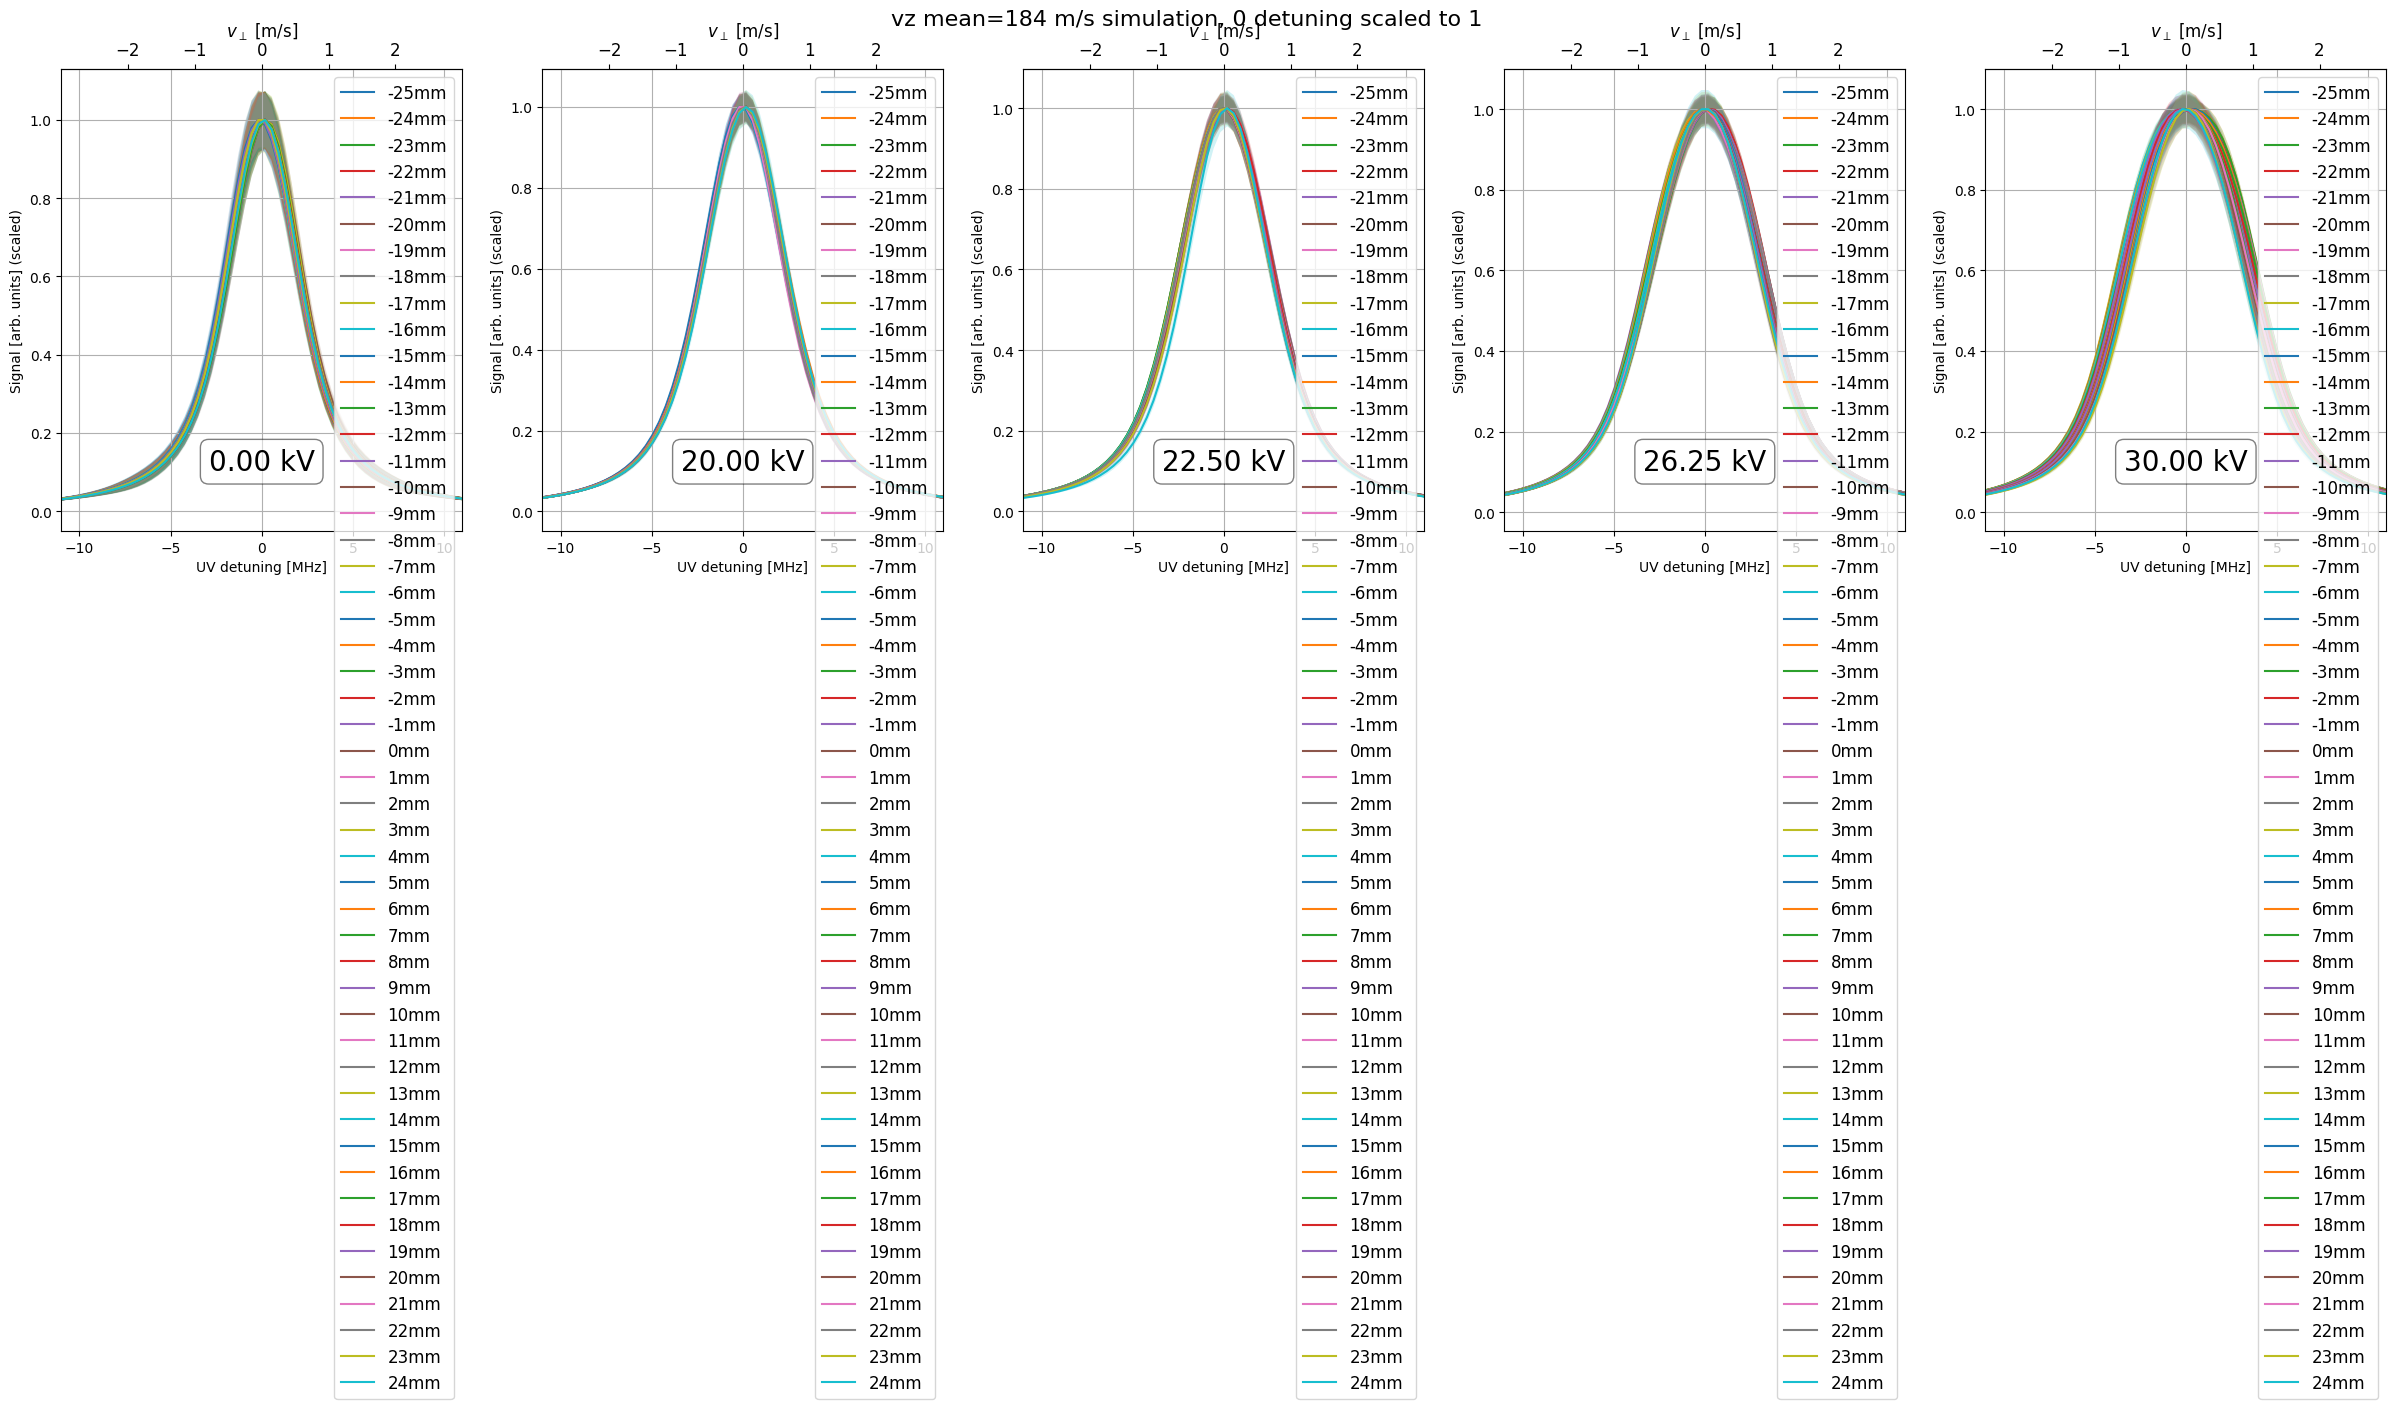

In [6]:

fig, axs = plt.subplots(1, 5, figsize=(30, 6), sharey=False)
velocity_to_detuning = 23054295.241468497 / (2 * np.pi * 1e6)
plt.rcParams.update({'font.size': 12})
from scipy.optimize import minimize

i = -1
j = 0
for aperture_size_x, data1 in signal_vs_detuning['mF=0'].items():
    for aperture_size_y, data2 in data1.items():
        for voltage, data3 in data2.items():
            if float(voltage)/1000 not in np.array([0,20,22.5, 26.25, 30.0]):
                print(f"Skipping voltage {voltage} kV")
                continue
            # if not (np.isclose(aperture_size_x, 0.02) and np.isclose(aperture_size_y, 0.005)) and True:
            #     continue
            i += 1
            ax2 = axs[i]
            secax2 = ax2.secondary_xaxis('top', functions=(lambda x: x / velocity_to_detuning, lambda x: x * velocity_to_detuning))
            secax2.set_xlabel(r"$v_\perp$ [m/s]")
            signal_vs_freq = None
            for param, data4 in data3['gaussian'].items():
                for h, data5 in data4.items():
                    # if 1000*h not in np.array([-20,-10,0,10,20]):
                    #     print(f"Skipping height {h*1000:.1f} mm")
                    #     continue
                    scale = 1/np.max([g.n for g in data5])
                    mask = np.array([g.n for g in data5]) > 0
                    ax2.fill_between(
                        4 * freqs[mask],
                        (np.array([g.n for g in data5]) + np.array([g.s for g in data5]))[mask] * scale,
                        (np.array([g.n for g in data5]) - np.array([g.s for g in data5]))[mask] * scale,
                        alpha=0.2,
                    )

                    line = ax2.plot(
                        4 * freqs[mask],
                        np.array([g.n for g in data5])[mask] * scale,
                        label=f"{h*1000:.0f}mm",
                    )

            j += 1
            ax2.text(
                0.5, 0.15, f"{float(voltage) / 1000:.2f} kV",
                transform=ax2.transAxes,
                fontsize=20,
                ha='center',
                va='center',
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
            )
            ax2.grid(True)
            ax2.set_xlim(-11, 11)
            ax2.set_xlabel("UV detuning [MHz]")
            ax2.set_ylabel("Signal [arb. units] (scaled)")
            ax2.legend(ncols=1)
fig.suptitle("vz mean=184 m/s simulation, 0 detuning scaled to 1", fontsize=16)

# Correlation Analysis

HV voltage 0.0 kV, Mutual Information: 0.0005 bits
Skipping voltage 10000.0 kV
Skipping voltage 15000.0 kV
HV voltage 20000.0 kV, Mutual Information: 0.0002 bits
Skipping voltage 21250.0 kV
HV voltage 22500.0 kV, Mutual Information: 0.0002 bits
Skipping voltage 23750.0 kV
Skipping voltage 25000.0 kV
HV voltage 26250.0 kV, Mutual Information: 0.0003 bits
Skipping voltage 27500.0 kV
Skipping voltage 28750.0 kV
HV voltage 30000.0 kV, Mutual Information: 0.0008 bits


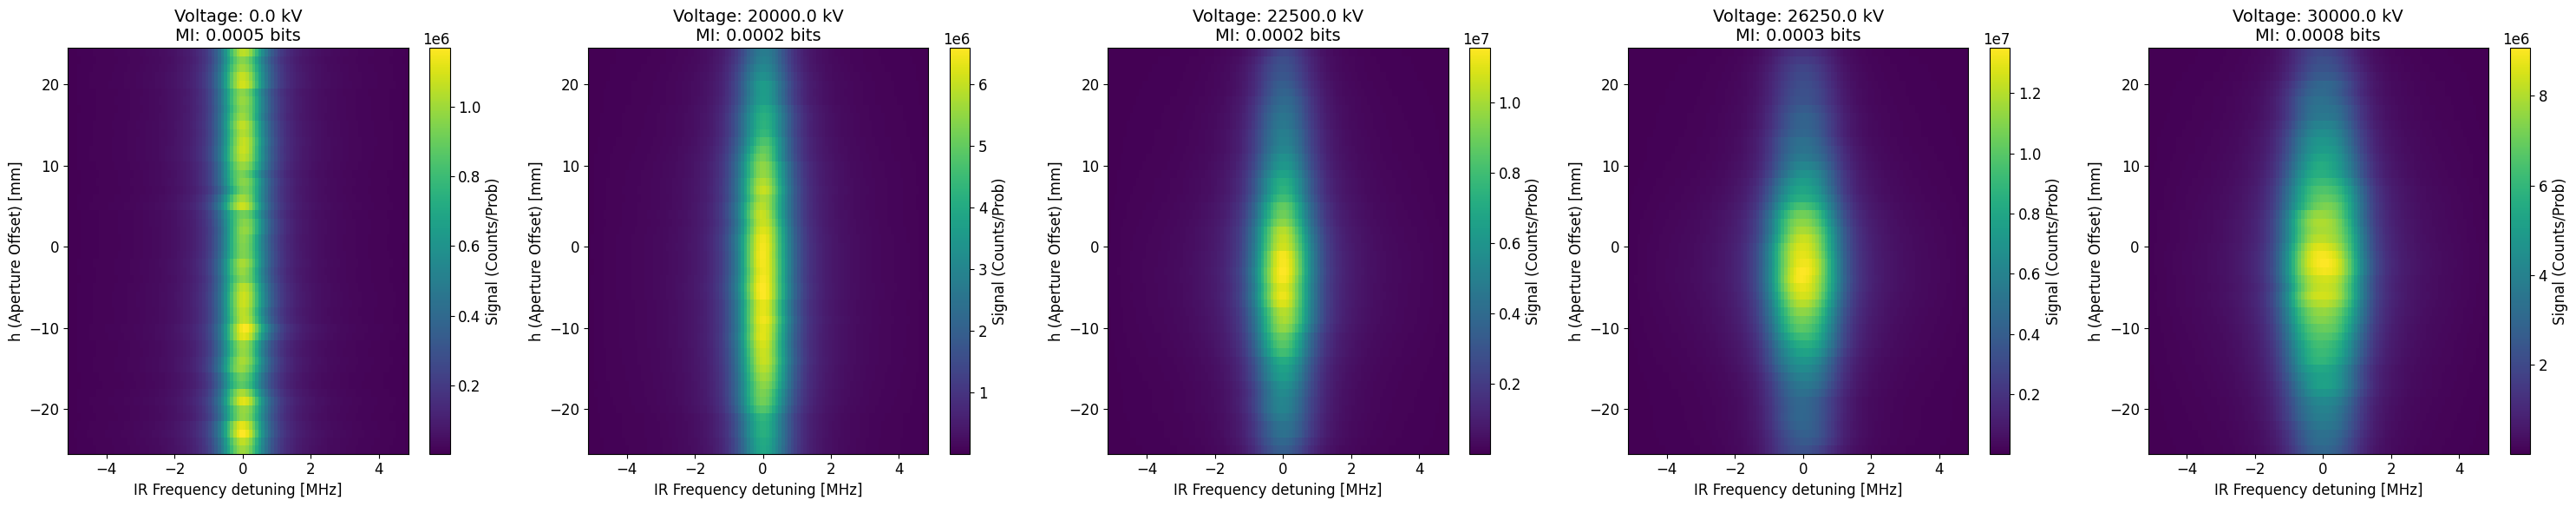

In [10]:
from sklearn.metrics import mutual_info_score

# Assuming 'freqs' is predefined somewhere above in your code
fig, axs = plt.subplots(1, 5, figsize=(30, 6), sharey=False)
i = 0

for aperture_size_x, data1 in signal_vs_detuning['mF=0'].items():
    for aperture_size_y, data2 in data1.items():
        for voltage, data3 in data2.items():
            if float(voltage)/1000 not in np.array([0,20,22.5, 26.25, 30.0]):
                print(f"Skipping voltage {voltage} kV")
                continue
            # Safety check to avoid IndexError if there are more than 5 voltages
            if i >= len(axs): 
                continue
                
            data4 = data3['gaussian']['0.0022']
            
            # Extract the keys for 'h'
            hs = list(data4.keys())  # Convert to mm for better readability in the plot

            # Build the 2D matrix. 
            # .T transposes it so Rows = param (freqs), Columns = h
            matrix_nominal = np.array([[val.n for val in data4[h]] for h in hs]).T

            # Calculate Mutual Information
            MI_nats = mutual_info_score(None, None, contingency=matrix_nominal)
            MI_bits = MI_nats / np.log(2)
            print(f"HV voltage {voltage} kV, Mutual Information: {MI_bits:.4f} bits")
            
            # --- Plotting Logic ---
            ax = axs[i]
            
            # pcolormesh expects Z to have shape (len(Y), len(X))
            # Since matrix_nominal is transposed to (freqs, hs), we transpose it back for plotting
            c = ax.pcolormesh(freqs, np.array(hs)*1000, matrix_nominal.T, shading='auto', cmap='viridis')
            
            # Formatting
            ax.set_title(f"Voltage: {voltage} kV\nMI: {MI_bits:.4f} bits", fontsize=14)
            ax.set_xlabel("IR Frequency detuning [MHz]", fontsize=12)
            
            if i == 0 or not axs[0].get_shared_y_axes().joined(axs[0], ax):
                ax.set_ylabel("h (Aperture Offset) [mm]", fontsize=12)
            
            # Add a colorbar to show the signal intensity scale
            fig.colorbar(c, ax=ax, label="Signal (Counts/Prob)")

            # Move to the next subplot
            i += 1

plt.tight_layout()
plt.show()